In [2]:
# Intall library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
# --- 1. DATA LOADING & PREPROCESSING ---
file_path = '/kaggle/input/aqi-data/air_quality_by_area/3276373.csv' 
df = pd.read_csv(file_path)

# In 10 bản ghi trong csv
print(df.head(10))

df['datetimeLocal'] = pd.to_datetime(df['datetimeLocal'])
df = df.sort_values('datetimeLocal')
df = df.set_index('datetimeLocal')
df = df.reindex(pd.date_range(start=df.index.min(), end=df.index.max(), freq='h'))
df = df.rename_axis('datetimeLocal').reset_index()
df['aqi_total'] = df['aqi_total'].interpolate(method='linear')

df['hour'] = df['datetimeLocal'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['aqi_total', 'hour_sin', 'hour_cos']
data = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

   sensor_id       area location_name  aqi_total              datetimeLocal
0    3276385  Hải Phòng      Việt Nam  56.869999  2021-11-29 20:00:00+07:00
1    3276385  Hải Phòng      Việt Nam  51.169998  2021-11-29 21:00:00+07:00
2    3276385  Hải Phòng      Việt Nam  49.880001  2021-11-29 22:00:00+07:00
3    3276385  Hải Phòng      Việt Nam  49.410000  2021-11-29 23:00:00+07:00
4    3276385  Hải Phòng      Việt Nam  71.610001  2021-11-30 00:00:00+07:00
5    3276385  Hải Phòng      Việt Nam  72.320000  2021-11-30 01:00:00+07:00
6    3276385  Hải Phòng      Việt Nam  72.269997  2021-11-30 02:00:00+07:00
7    3276385  Hải Phòng      Việt Nam  70.209999  2021-11-30 03:00:00+07:00
8    3276385  Hải Phòng      Việt Nam  52.779999  2021-11-30 04:00:00+07:00
9    3276385  Hải Phòng      Việt Nam  50.900002  2021-11-30 05:00:00+07:00


In [4]:
# --- 2. CREATE MULTI-OUTPUT DATASET ---
def create_multi_dataset(dataset, look_back=72, forecast_horizon=24):
    X, y = [], []
    # Chỉnh điều kiện dừng để không bị tràn mảng khi lấy 24 giờ tương lai
    for i in range(len(dataset) - look_back - forecast_horizon + 1):
        X.append(dataset[i : (i + look_back), :])        # 72 giờ quá khứ (3 features)
        y.append(dataset[(i + look_back) : (i + look_back + forecast_horizon), 0]) # 24 giờ tương lai (chỉ AQI)
    return np.array(X), np.array(y)

look_back = 72 
forecast_horizon = 24 # Dự báo 24 giờ
X, y = create_multi_dataset(scaled_data, look_back, forecast_horizon)

# Split Train/Test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [5]:

# --- 3. MULTI-OUTPUT MODEL ARCHITECTURE ---
model = Sequential()
model.add(Bidirectional(LSTM(units=128, return_sequences=True), input_shape=(look_back, 3)))
model.add(Dropout(0.3))

model.add(Bidirectional(GRU(units=64, return_sequences=False)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dense(forecast_horizon)) # Output là 24 nơ-ron

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

print("Training Multi-output model...")
history = model.fit(
    X_train, y_train, 
    epochs=200, 
    batch_size=512, 
    validation_data=(X_test, y_test), 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

I0000 00:00:1767065726.093519      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Multi-output model...
Epoch 1/200


I0000 00:00:1767065731.102899     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - loss: 0.0744 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 2/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0210 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 3/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0137 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 4/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0113 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 5/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0103 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 6/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0098 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 7/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0092 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 8/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0087 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 9/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0082 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 10/200
84/84 ━━

In [6]:
# --- 4. EVALUATION & INVERSE TRANSFORM ---
predictions_scaled = model.predict(X_test)

def inverse_transform_24h(scaled_array, scaler):
    """Hàm giải chuẩn hóa cho kết quả 24 giờ"""
    inverted = np.zeros(scaled_array.shape)
    for i in range(scaled_array.shape[1]): # Lặp qua 24 cột
        dummy = np.zeros((len(scaled_array), 3))
        dummy[:, 0] = scaled_array[:, i]
        inverted[:, i] = scaler.inverse_transform(dummy)[:, 0]
    return inverted

y_test_actual = inverse_transform_24h(y_test, scaler)
predictions_actual = inverse_transform_24h(predictions_scaled, scaler)

# Tính sai số trung bình cho toàn bộ 24 giờ
rmse = math.sqrt(mean_squared_error(y_test_actual, predictions_actual))
r2 = r2_score(y_test_actual.flatten(), predictions_actual.flatten())

print(f"\n--- MULTI-OUTPUT EVALUATION ---")
print(f"Overall RMSE: {rmse:.2f}")
print(f"Overall R2 Score: {r2:.4f}")

333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

--- MULTI-OUTPUT EVALUATION ---
Overall RMSE: 3.24
Overall R2 Score: 0.9497


In [7]:
# --- 5. LƯU MODEL VÀ SCALER ---
model.save('aqi_model_24h.keras')
joblib.dump(scaler, 'aqi_scaler_24h.pkl')

['aqi_scaler_24h.pkl']

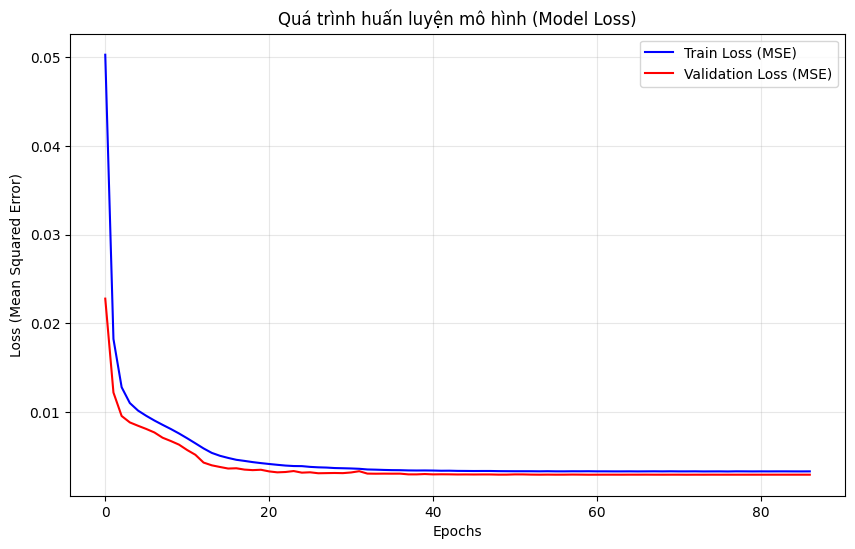

In [8]:
# --- 6. VẼ BIỂU ĐỒ LOSS ---
def plot_learning_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red')
    
    plt.title('Quá trình huấn luyện mô hình (Model Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Gọi hàm để vẽ
plot_learning_curves(history)

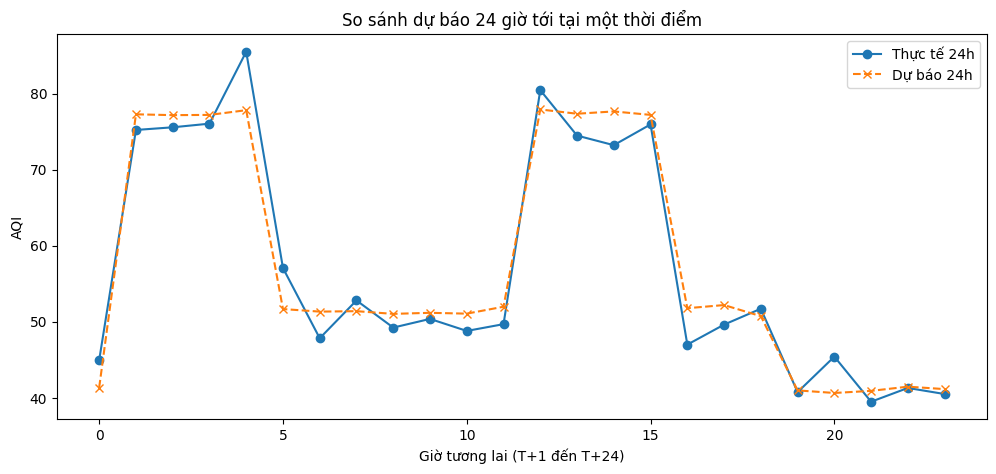

In [9]:
# --- 7. TRỰC QUAN HÓA MỘT MẪU DỰ BÁO ---
plt.figure(figsize=(12, 5))
sample_idx = 0 # Lấy mẫu đầu tiên trong tập test
plt.plot(range(24), y_test_actual[sample_idx], label='Thực tế 24h', marker='o')
plt.plot(range(24), predictions_actual[sample_idx], label='Dự báo 24h', marker='x', linestyle='--')
plt.title('So sánh dự báo 24 giờ tới tại một thời điểm')
plt.xlabel('Giờ tương lai (T+1 đến T+24)')
plt.ylabel('AQI')
plt.legend()
plt.show()